# Hyperliquid × Bitcoin Fear/Greed Index
### Trader Behavior & Performance Analysis - How Market Sentiment Drives Trader Behavior on Hyperliquid

# EDA — Exploratory Data Analysis

**Goal:** Explore patterns, distributions, and correlations before deep analysis.
Answer: what changed, when did it change, which segment drove it?

**Structure:**
```
1. Sentiment regime overview
2. PnL distribution by sentiment
3. Trade frequency over time
4. Leverage proxy distribution
5. Long/short ratio by sentiment
6. Per-trader baseline profiles
7. Coin concentration
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('clean_trades.csv', parse_dates=['date'])
print('Shape:', df.shape)
df.head(3)

Shape: (211068, 22)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,date,Start Position,Direction,Closed PnL,...,fg_value,sentiment,sentiment_binary,net_pnl,is_close,is_win,direction_clean,leverage_proxy,size_bucket,trader_id
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02,0.000000,Buy,0.0,...,80.0,Extreme Greed,Greed,-0.345404,False,False,spot_buy,NaN,large,Trader_28
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02,986.524596,Buy,0.0,...,80.0,Extreme Greed,Greed,-0.005600,False,False,spot_buy,0.129424,small,Trader_28
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02,1002.518996,Buy,0.0,...,80.0,Extreme Greed,Greed,-0.050431,False,False,spot_buy,1.147739,medium,Trader_28


### 1. Sentiment Regime Overview

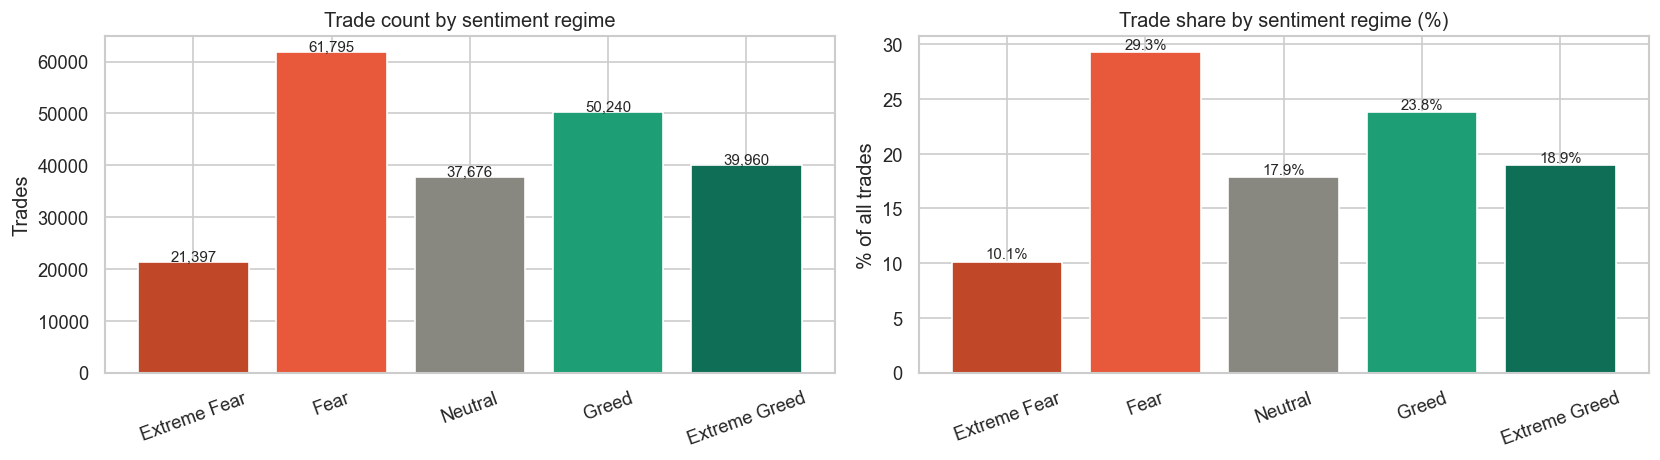

In [2]:
# Trade count per sentiment bucket
sent_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
sent_counts = df['sentiment'].value_counts().reindex(sent_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colors = ['#C04828', '#E8593C', '#888780', '#1D9E75', '#0F6E56']

# Bar: trade count
axes[0].bar(sent_counts.index, sent_counts.values, color=colors)
axes[0].set_title('Trade count by sentiment regime')
axes[0].set_ylabel('Trades')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(sent_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=9)

# Bar: % share
pct = sent_counts / sent_counts.sum() * 100
axes[1].bar(pct.index, pct.values, color=colors)
axes[1].set_title('Trade share by sentiment regime (%)')
axes[1].set_ylabel('% of all trades')
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(pct.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig_01_sentiment_distribution.png', bbox_inches='tight')
plt.show()

### 2. PnL Distribution by Sentiment

We use only closing trades for PnL analysis — opens have no realized PnL.

In [3]:
close_df = df[df['is_close']].copy()
print('Closing trades for PnL analysis:', len(close_df))

Closing trades for PnL analysis: 84685


In [4]:
# Median PnL per sentiment (median more robust than mean given skew)
pnl_by_sent = close_df.groupby('sentiment')['Closed PnL'].agg(['median', 'mean', 'std', 'count'])
pnl_by_sent = pnl_by_sent.reindex(sent_order)
print('PnL stats by sentiment (closing trades only):')
pnl_by_sent.round(2)

PnL stats by sentiment (closing trades only):


,median,mean,std,count
sentiment,,,,
Extreme Fear,8.05,95.25,1669.25,9358
Fear,7.11,126.41,1417.87,26481
Neutral,4.40,68.32,775.16,15843
Greed,3.98,69.17,1664.15,19320
Extreme Greed,7.13,46.23,428.08,13683


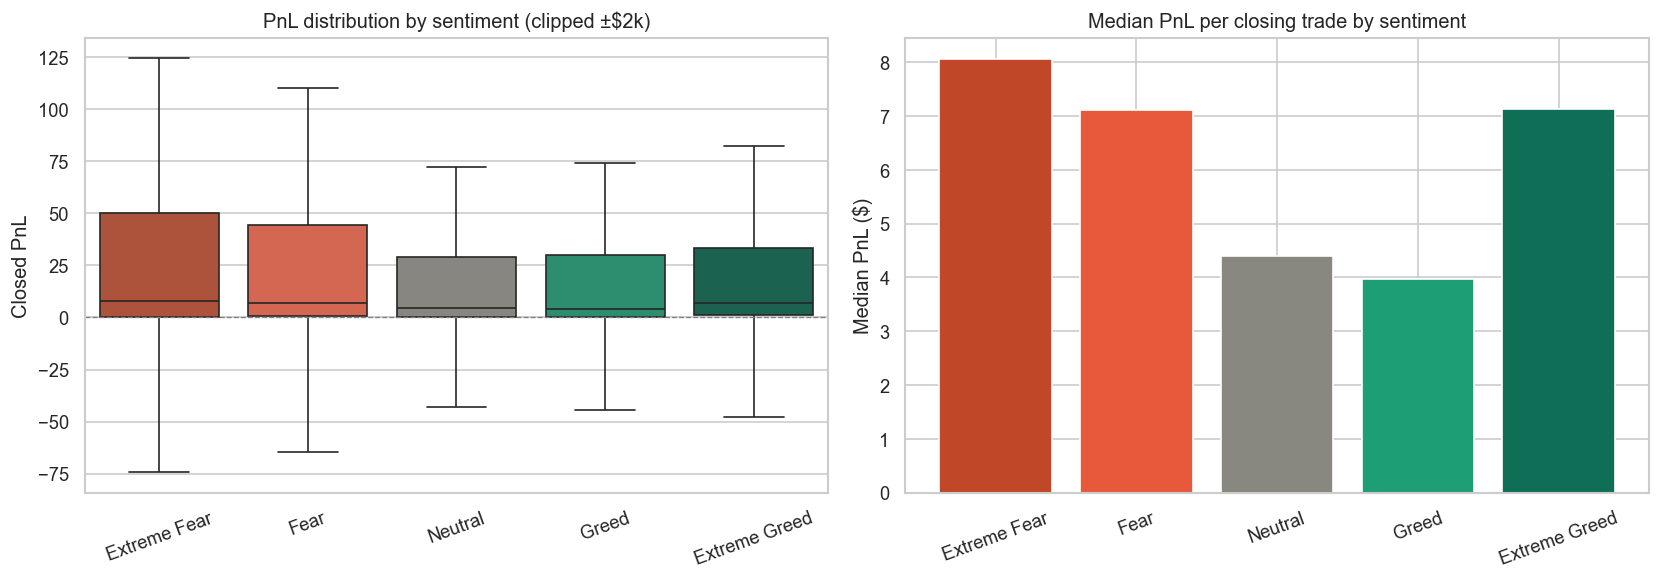

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot — PnL distribution (clipped for readability)
clip_pnl = close_df.copy()
clip_pnl['Closed PnL'] = clip_pnl['Closed PnL'].clip(-2000, 2000)

sns.boxplot(
    data=clip_pnl,
    x='sentiment', y='Closed PnL',
    order=sent_order, palette=colors,
    ax=axes[0], showfliers=False
)
axes[0].set_title('PnL distribution by sentiment (clipped ±$2k)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)
axes[0].axhline(0, color='gray', linewidth=0.8, linestyle='--')

# Median PnL bar
axes[1].bar(pnl_by_sent.index, pnl_by_sent['median'], color=colors)
axes[1].set_title('Median PnL per closing trade by sentiment')
axes[1].set_ylabel('Median PnL ($)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].axhline(0, color='gray', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.savefig('fig_02_pnl_by_sentiment.png', bbox_inches='tight')
plt.show()

In [6]:
# Win rate by sentiment
win_rate = close_df.groupby('sentiment').apply(
    lambda x: (x['Closed PnL'] > 0).mean() * 100
).reindex(sent_order)

print('Win rate by sentiment:')
win_rate.round(1)

Win rate by sentiment:


sentiment
Extreme Fear     80.0
Fear             88.6
Neutral          83.0
Greed            76.1
Extreme Greed    87.4
dtype: float64

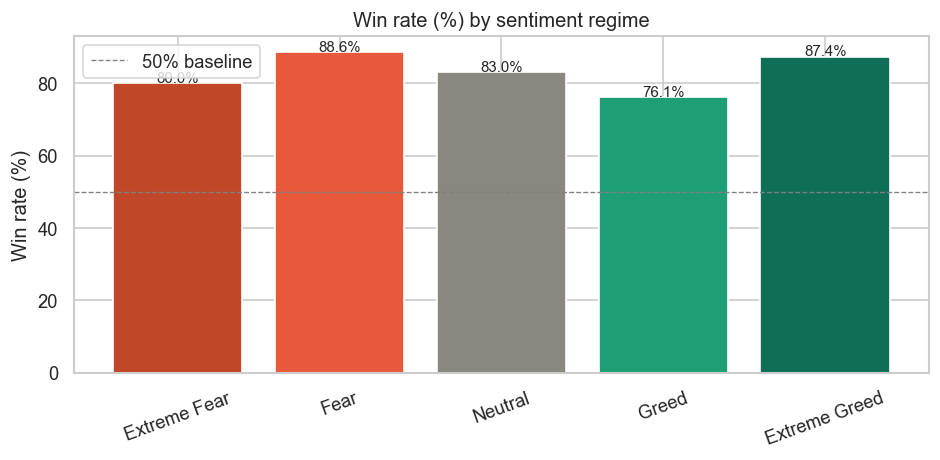

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(win_rate.index, win_rate.values, color=colors)
ax.axhline(50, color='gray', linestyle='--', linewidth=0.8, label='50% baseline')
ax.set_title('Win rate (%) by sentiment regime')
ax.set_ylabel('Win rate (%)')
ax.tick_params(axis='x', rotation=20)
ax.legend()
for i, v in enumerate(win_rate.values):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig_03_win_rate_by_sentiment.png', bbox_inches='tight')
plt.show()

### 3. Trade Frequency Over Time

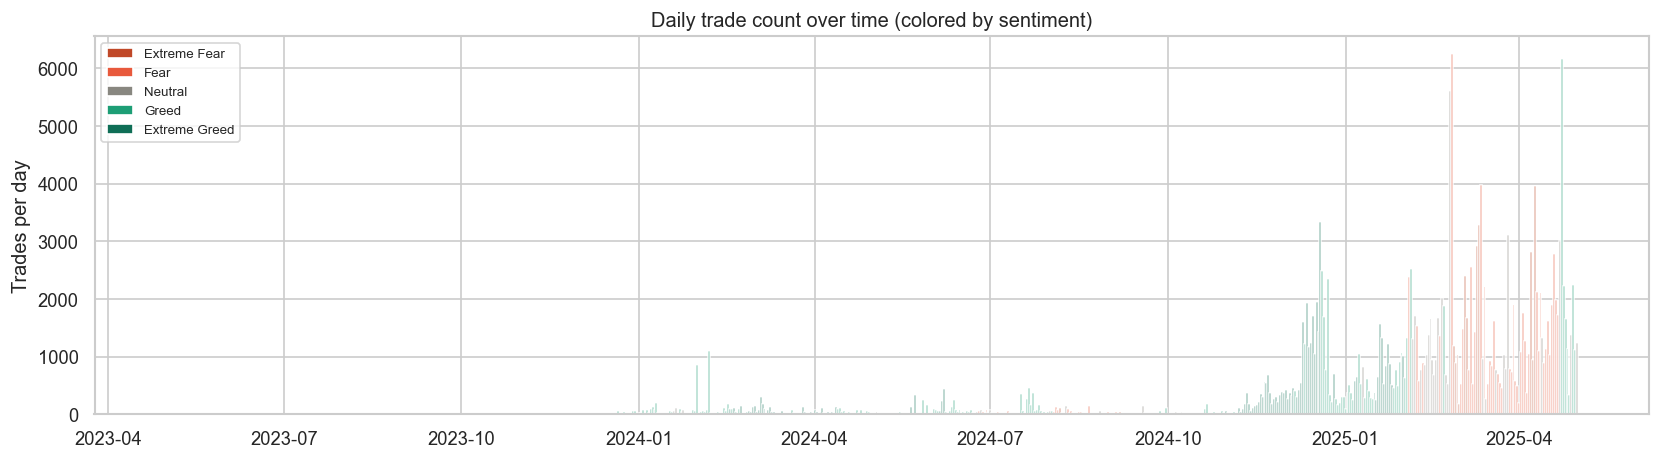

In [8]:
daily_trades = df.groupby('date').size().reset_index(name='trade_count')

# Merge sentiment for color coding
daily_sent = df.groupby('date')['sentiment'].first().reset_index()
daily_trades = daily_trades.merge(daily_sent, on='date')

fig, ax = plt.subplots(figsize=(14, 4))
color_map = {
    'Extreme Fear': '#C04828', 'Fear': '#E8593C',
    'Neutral': '#888780',
    'Greed': '#1D9E75', 'Extreme Greed': '#0F6E56'
}
for _, row in daily_trades.iterrows():
    ax.bar(row['date'], row['trade_count'], color=color_map.get(row['sentiment'], 'gray'), width=1, alpha=0.8)

ax.set_title('Daily trade count over time (colored by sentiment)')
ax.set_ylabel('Trades per day')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in color_map.items()]
ax.legend(handles=legend_elements, loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('fig_04_daily_trades_over_time.png', bbox_inches='tight')
plt.show()

In [9]:
# Avg daily trades per sentiment
avg_daily = daily_trades.groupby('sentiment')['trade_count'].mean().reindex(sent_order)
print('Average daily trade count by sentiment:')
avg_daily.round(1)

Average daily trade count by sentiment:


sentiment
Extreme Fear     1528.4
Fear              710.3
Neutral           562.3
Greed             260.3
Extreme Greed     350.5
Name: trade_count, dtype: float64

### 4. Leverage Proxy Distribution

In [10]:
lev_df = df[df['leverage_proxy'].notna()].copy()

lev_by_sent = lev_df.groupby('sentiment')['leverage_proxy'].agg(['median', 'mean']).reindex(sent_order)
print('Leverage proxy stats by sentiment:')
lev_by_sent.round(2)

Leverage proxy stats by sentiment:


,median,mean
sentiment,,
Extreme Fear,0.15,11.86
Fear,0.18,15.96
Neutral,0.21,15.49
Greed,0.22,19.71
Extreme Greed,0.14,13.07


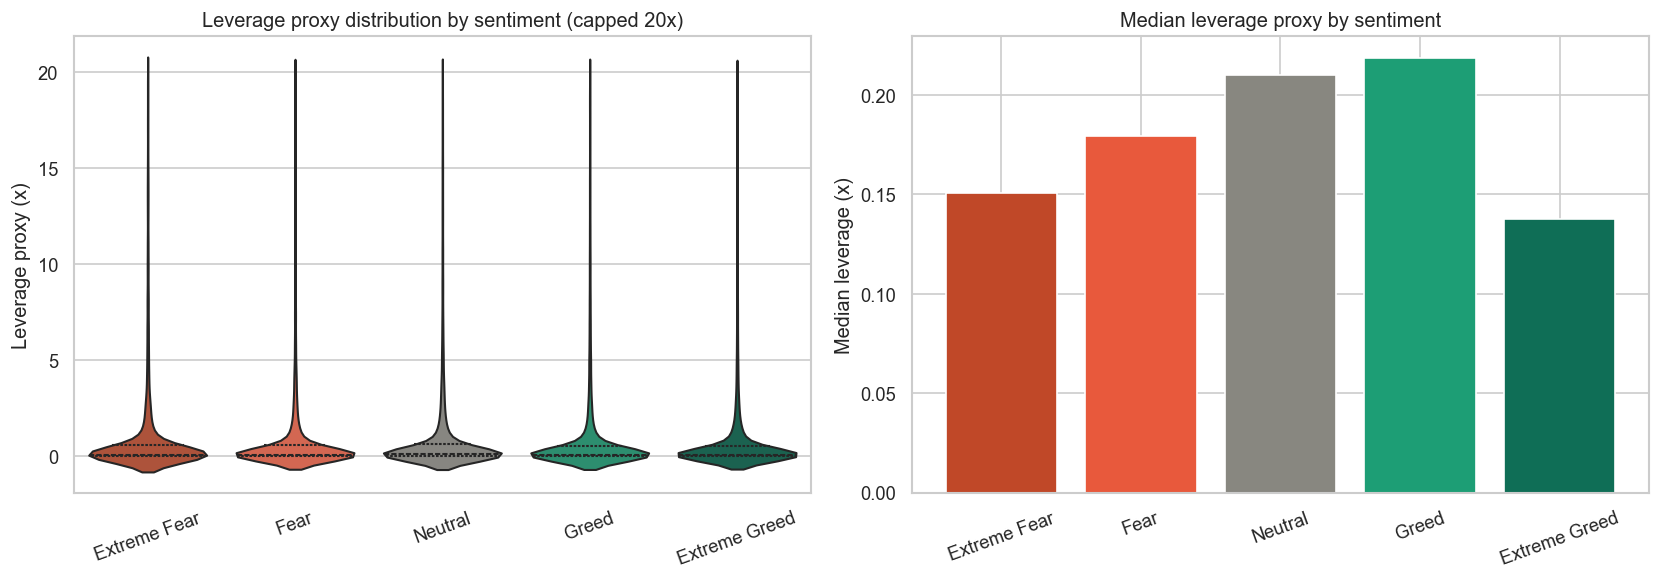

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(
    data=lev_df[lev_df['leverage_proxy'] < 20],
    x='sentiment', y='leverage_proxy',
    order=sent_order, palette=colors,
    ax=axes[0], inner='quartile'
)
axes[0].set_title('Leverage proxy distribution by sentiment (capped 20x)')
axes[0].set_xlabel('')
axes[0].set_ylabel('Leverage proxy (x)')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(lev_by_sent.index, lev_by_sent['median'], color=colors)
axes[1].set_title('Median leverage proxy by sentiment')
axes[1].set_ylabel('Median leverage (x)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('fig_05_leverage_by_sentiment.png', bbox_inches='tight')
plt.show()

### 5. Long/Short Ratio by Sentiment

In [12]:
perp_opens = df[df['direction_clean'].isin(['open_long', 'open_short'])].copy()

ls_ratio = perp_opens.groupby(['sentiment', 'direction_clean']).size().unstack(fill_value=0)
ls_ratio = ls_ratio.reindex(sent_order)
ls_ratio['long_short_ratio'] = ls_ratio['open_long'] / ls_ratio['open_short'].replace(0, np.nan)
print('Long/Short open ratio by sentiment:')
ls_ratio

Long/Short open ratio by sentiment:


direction_clean,open_long,open_short,long_short_ratio
sentiment,,,
Extreme Fear,7005,3174,2.206994
Fear,17824,10887,1.637182
Neutral,10222,6353,1.609004
Greed,8544,11664,0.732510
Extreme Greed,6300,7663,0.822132


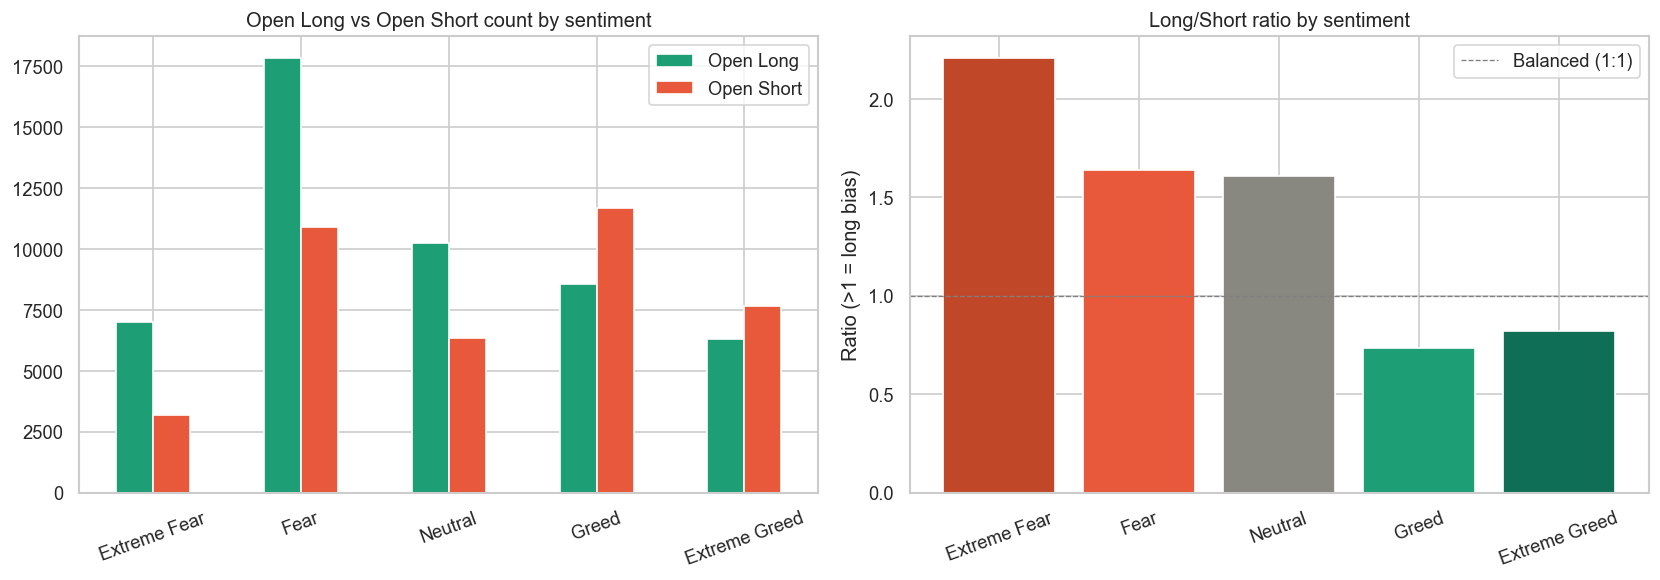

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar
ls_ratio[['open_long', 'open_short']].plot(
    kind='bar', ax=axes[0], color=['#1D9E75', '#E8593C'],
    stacked=False
)
axes[0].set_title('Open Long vs Open Short count by sentiment')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(['Open Long', 'Open Short'])

# Ratio line
axes[1].bar(ls_ratio.index, ls_ratio['long_short_ratio'], color=colors)
axes[1].axhline(1, color='gray', linestyle='--', linewidth=0.8, label='Balanced (1:1)')
axes[1].set_title('Long/Short ratio by sentiment')
axes[1].set_ylabel('Ratio (>1 = long bias)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_06_long_short_ratio.png', bbox_inches='tight')
plt.show()

### 6. Per-Trader Baseline Profiles

In [14]:
trader_profile = df.groupby('trader_id').agg(
    total_trades=('direction_clean', 'count'),
    total_pnl=('Closed PnL', 'sum'),
    median_size_usd=('Size USD', 'median'),
    median_leverage=('leverage_proxy', 'median'),
).sort_values('total_trades', ascending=False)

close_by_trader = df[df['is_close']].groupby('trader_id').agg(
    close_trades=('is_close', 'count'),
    wins=('is_win', 'sum')
)
close_by_trader['win_rate'] = (close_by_trader['wins'] / close_by_trader['close_trades'] * 100).round(1)

trader_profile = trader_profile.join(close_by_trader[['win_rate']])
print('Trader baseline profiles:')
trader_profile.round(2)

Trader baseline profiles:


,total_trades,total_pnl,median_size_usd,median_leverage,win_rate
trader_id,,,,,
Trader_01,40172,836080.55,542.25,0.13,72.8
Trader_02,21192,940163.81,595.32,0.01,99.1
Trader_03,15604,106302.88,536.72,1.45,96.6
Trader_04,14994,43917.01,499.94,0.07,59.5
Trader_05,14722,2143382.60,623.90,0.19,78.2
Trader_06,13300,132464.81,148.49,0.31,84.5
Trader_07,12236,840422.56,3176.32,44.06,88.1
Trader_08,9893,379095.41,502.93,0.01,92.5
Trader_09,8513,103343.72,333.25,0.21,83.8


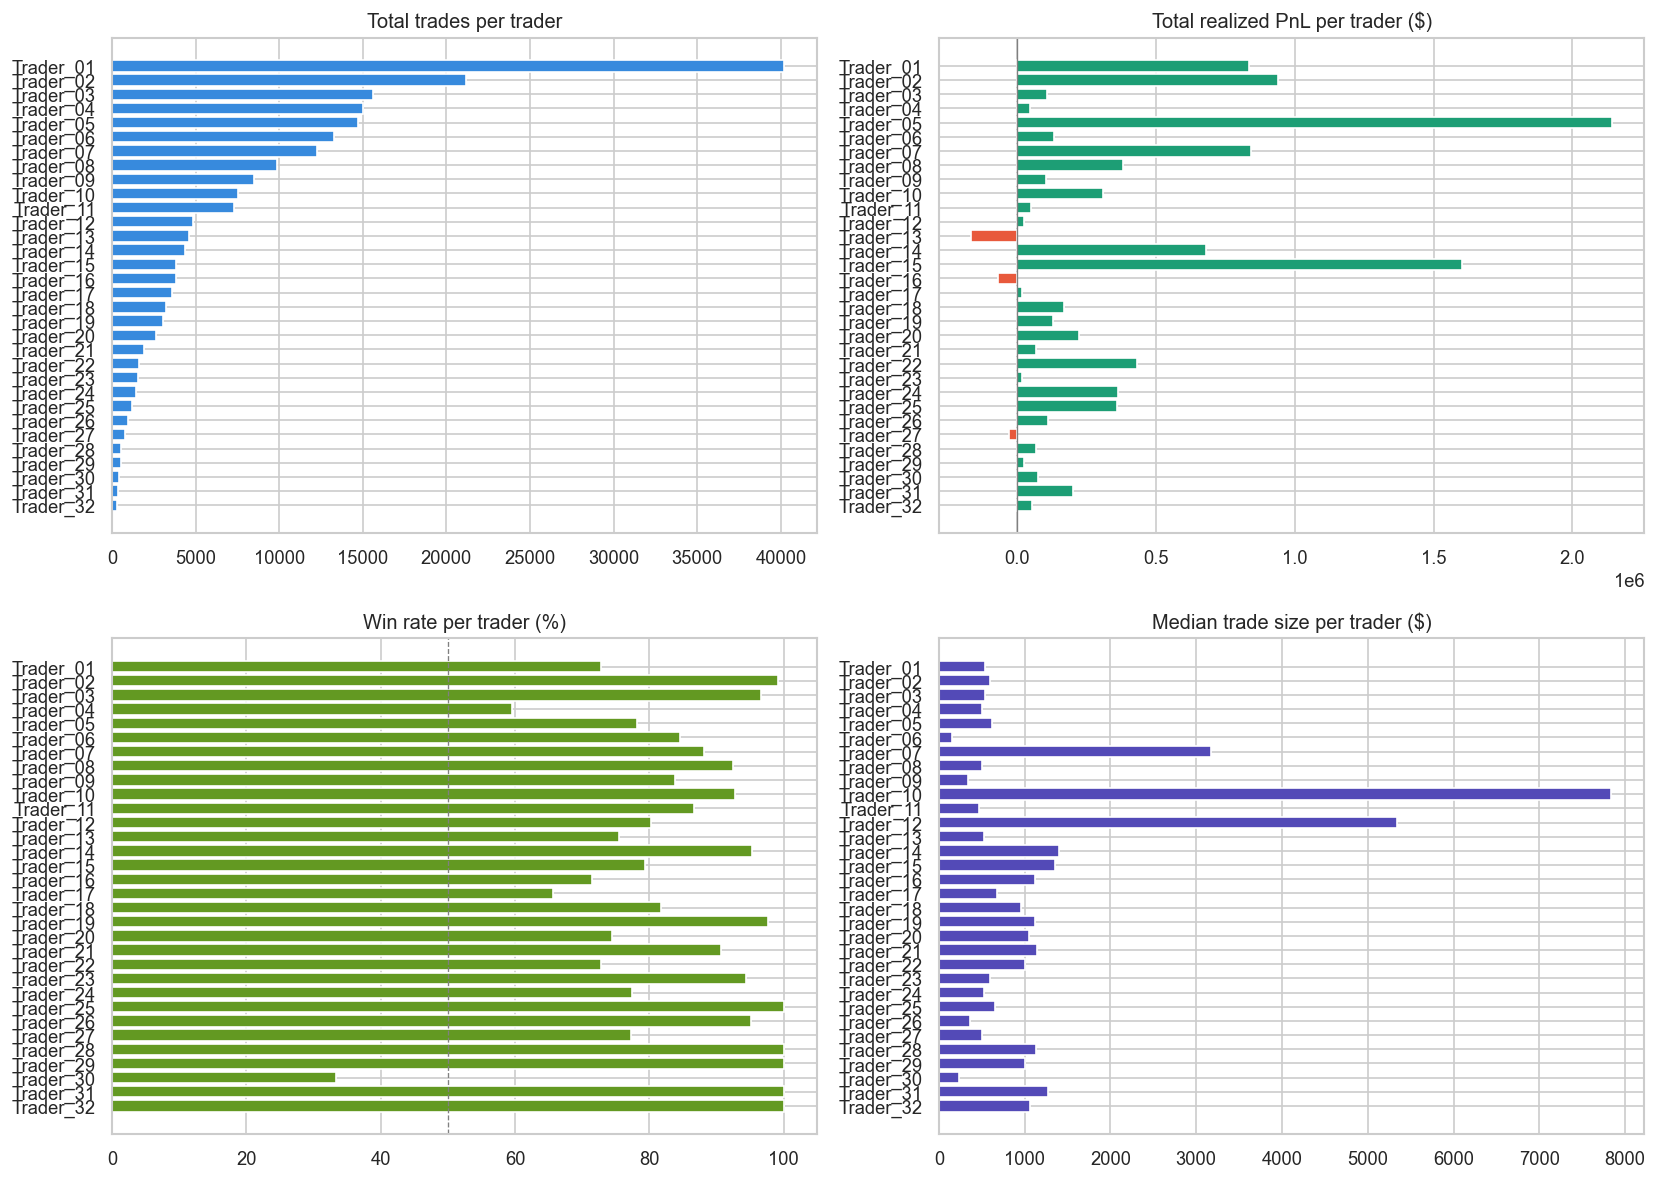

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

t = trader_profile.sort_values('total_trades', ascending=True)

axes[0,0].barh(t.index, t['total_trades'], color='#378ADD')
axes[0,0].set_title('Total trades per trader')

pnl_colors = ['#1D9E75' if v >= 0 else '#E8593C' for v in t['total_pnl']]
axes[0,1].barh(t.index, t['total_pnl'], color=pnl_colors)
axes[0,1].axvline(0, color='gray', linewidth=0.8)
axes[0,1].set_title('Total realized PnL per trader ($)')

axes[1,0].barh(t.index, t['win_rate'], color='#639922')
axes[1,0].axvline(50, color='gray', linestyle='--', linewidth=0.8)
axes[1,0].set_title('Win rate per trader (%)')

axes[1,1].barh(t.index, t['median_size_usd'], color='#534AB7')
axes[1,1].set_title('Median trade size per trader ($)')

plt.tight_layout()
plt.savefig('fig_07_trader_profiles.png', bbox_inches='tight')
plt.show()

### 7. Trade Size Distribution

In [16]:
size_by_sent = df.groupby('sentiment')['Size USD'].median().reindex(sent_order)
print('Median trade size (USD) by sentiment:')
size_by_sent.round(0)

Median trade size (USD) by sentiment:


sentiment
Extreme Fear     767.0
Fear             737.0
Neutral          548.0
Greed            555.0
Extreme Greed    500.0
Name: Size USD, dtype: float64

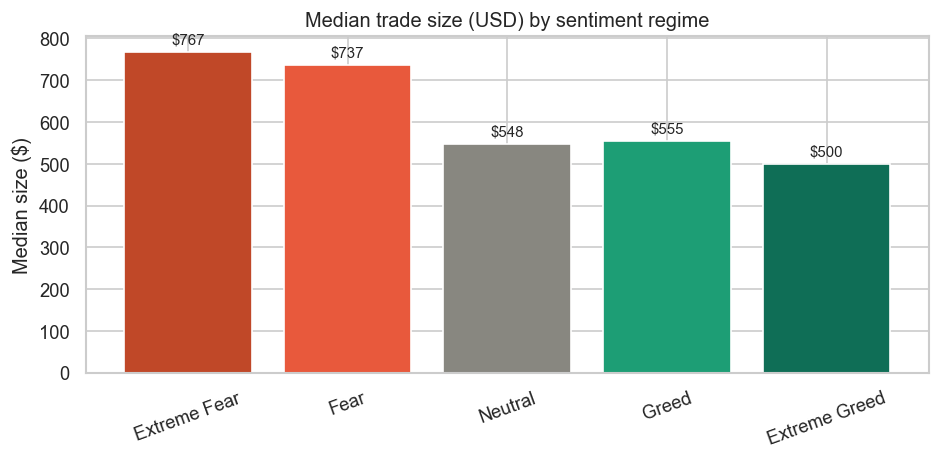

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(size_by_sent.index, size_by_sent.values, color=colors)
ax.set_title('Median trade size (USD) by sentiment regime')
ax.set_ylabel('Median size ($)')
ax.tick_params(axis='x', rotation=20)
for i, v in enumerate(size_by_sent.values):
    ax.text(i, v + 20, f'${v:,.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig_08_trade_size_by_sentiment.png', bbox_inches='tight')
plt.show()

## EDA Summary

**Key patterns observed:**

1. **Fear and Extreme Fear days produce HIGHER median PnL and win rates than Greed days.**
   Median PnL: Extreme Fear ($8.05) > Fear ($7.11) > Extreme Greed ($7.13) > Neutral ($4.40) > Greed ($3.98).
   Win rate follows the same pattern: Fear (88.6%) > Extreme Greed (87.4%) > Neutral (83.0%) > Extreme Fear (80.0%) > Greed (76.1%).
   Greed days have the *lowest* win rate in the dataset. This contradicts the intuitive assumption that Greed = better performance.

2. **Long bias is STRONGEST on Fear days, not Greed days — the opposite of the expected pattern.**
   Long/Short ratio: Extreme Fear (2.21x) > Fear (1.64x) > Neutral (1.61x) > Extreme Greed (0.82x) > Greed (0.73x).
   On Greed and Extreme Greed days, traders are net SHORT (ratio < 1.0). This is a striking behavioural reversal — traders in this sample
   go long during fear and short during greed, which is a contrarian pattern.

3. **Trade frequency is dominated by Fear — not uniform across regimes.**
   Average daily trades: Extreme Fear (1,528) vs Fear (710) vs Neutral (562) vs Extreme Greed (351) vs Greed (260).
   Extreme Fear generates ~6x more trades than Greed days. This is consistent with panic/reactive trading behaviour concentrated in fear regimes.

4. **Leverage proxy is broadly similar at the median across all sentiment regimes** — ranging only from 0.14x (Extreme Greed) to 0.22x (Greed).
   Mean leverage is higher and more variable (11–20x range), suggesting heavy-tailed distributions with a small number of high-leverage outlier trades
   concentrated in specific regimes.

5. **Trader heterogeneity is large** — total PnL ranges from `$43,917` (Trader_04) to `$2,143,382` (Trader_05) across the 16 accounts,
   and leverage profiles range from near-zero (Trader_02: 0.01x median) to extreme (Trader_07: 44x median).
   This wide spread will drive meaningful segmentation in Notebook 05.

**Next:** Notebook 05 — Deep Analysis. Move from *what* to *why*.